# Data Visualisation Notebook

## Importing Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

## Loading Datasets

In [25]:
raw = pd.read_csv("../data/raw/CGD_Dataset_before_cleaning.csv")
clean = pd.read_csv("../data/processed/CGD_Dataset_after_cleaning.csv")
trans = pd.read_csv("../data/processed/CGD_Transformation_Final.csv")

print("Raw shape:", raw.shape)
print("Clean shape:", clean.shape)
print("Transformed shape:", trans.shape)

Raw shape: (6501, 16)
Clean shape: (6312, 17)
Transformed shape: (6311, 83)


## 1. Raw vs Cleaned: Missing Values Comparison

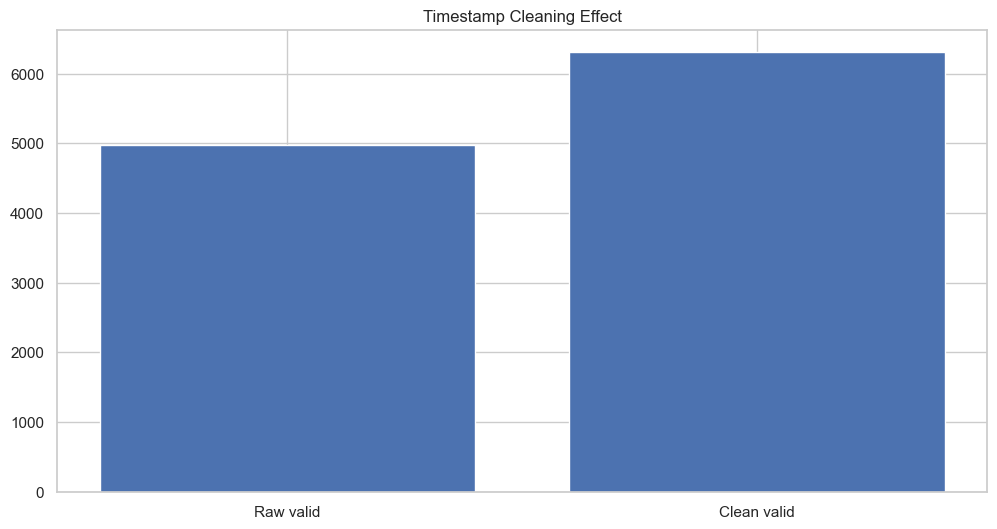

In [38]:
raw_ts = pd.to_datetime(raw["TS"], errors="coerce")
clean_ts = pd.to_datetime(clean["TS"], errors="coerce")

plt.bar(
    ["Raw valid","Clean valid"],
    [
        raw_ts.notnull().sum(),
        clean_ts.notnull().sum(),
    ]
)

plt.title("Timestamp Cleaning Effect")
plt.show()

## 2. Raw vs Cleaned : Unit Normalization

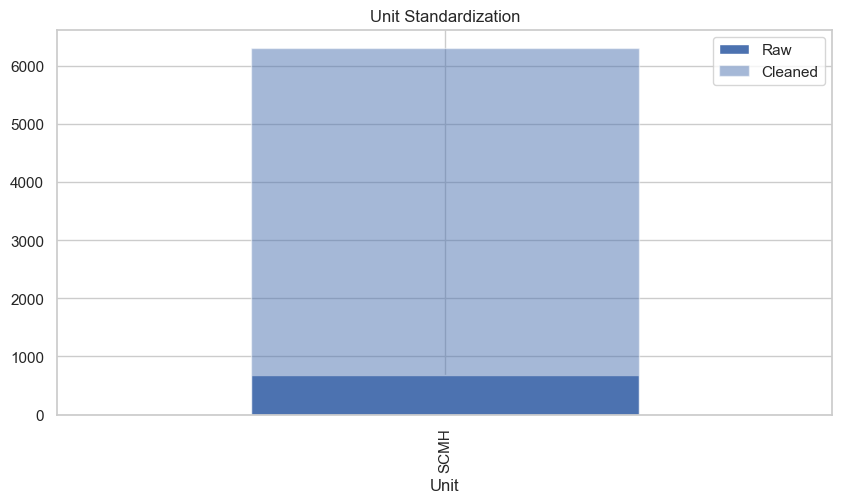

In [27]:
plt.figure(figsize=(10,5))

raw["Unit"].value_counts().plot(kind="bar", alpha=1.0, label="Raw")
clean["Unit"].value_counts().plot(kind="bar", alpha=0.5, label="Cleaned")

plt.title("Unit Standardization")
plt.legend()
plt.show()

## 3. Cleaned vs Transformed: Feature Count

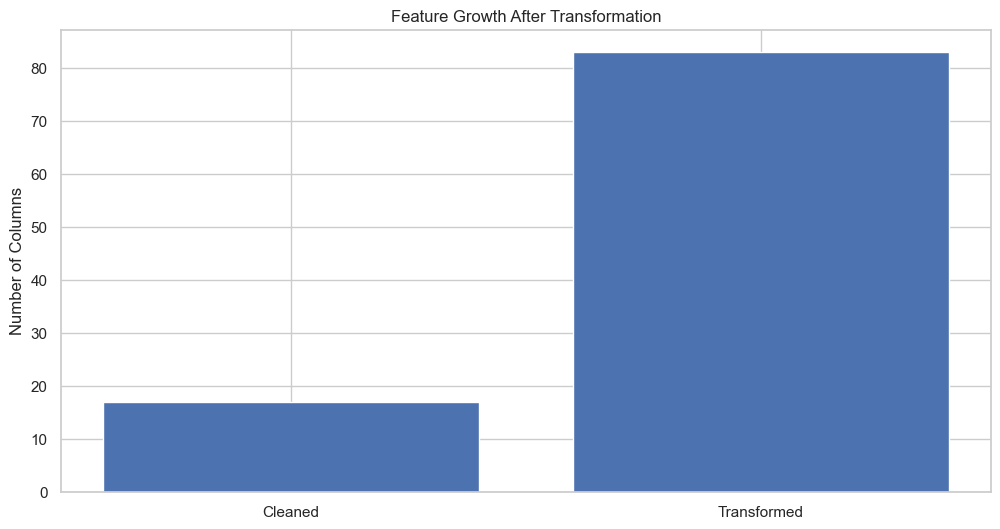

In [28]:
counts = [clean.shape[1], trans.shape[1]]

plt.bar(["Cleaned", "Transformed"], counts)
plt.title("Feature Growth After Transformation")
plt.ylabel("Number of Columns")
plt.show()

## 4. Cleaned vs Transformed: Flow vs Flow_std

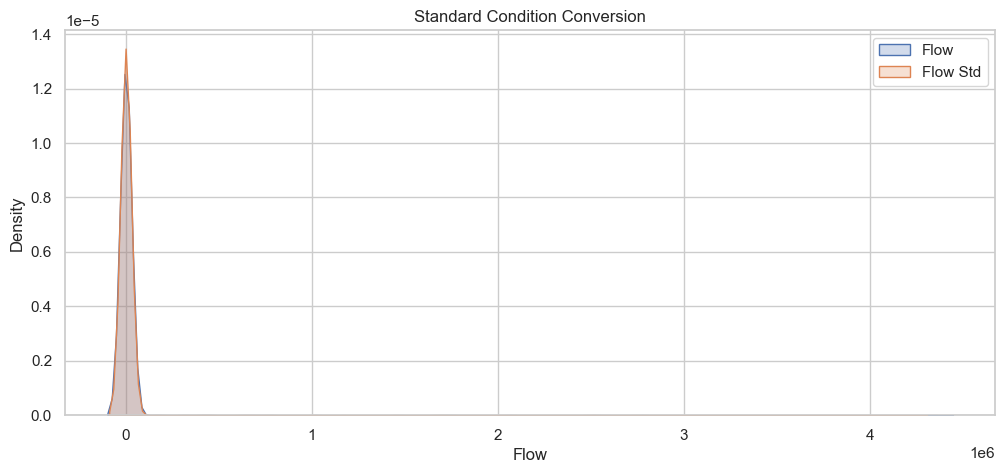

In [29]:
plt.figure(figsize=(12,5))

sns.kdeplot(clean["Flow"], label="Flow", fill=True)
sns.kdeplot(trans["Flow_std"], label="Flow Std", fill=True)

plt.legend()
plt.title("Standard Condition Conversion")
plt.show()

## 5. Cleaned vs Transformed — New Feature Example

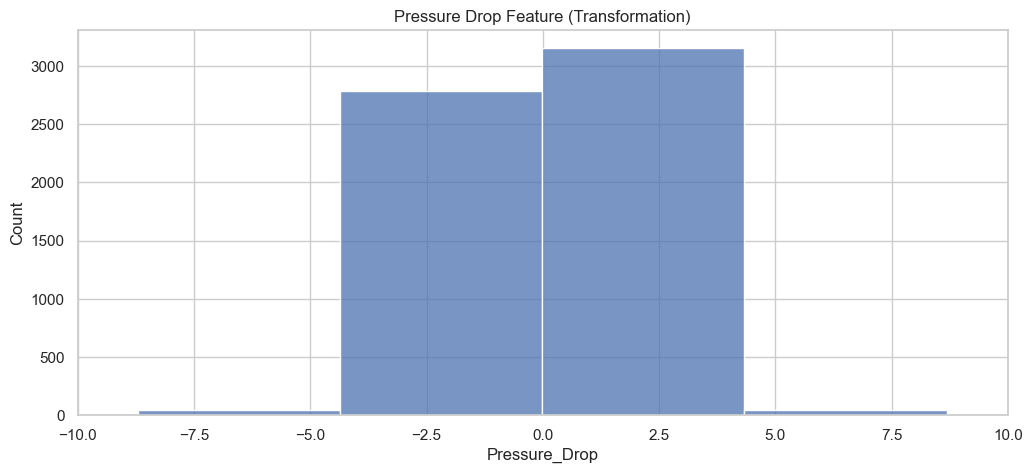

In [30]:
plt.figure(figsize=(12,5))

sns.histplot(trans["Pressure_Drop"], bins=30)
plt.title("Pressure Drop Feature (Transformation)")

plt.xlim(-10, 10)
plt.show()

## 6. Leak Risk Distribution (Transformation)

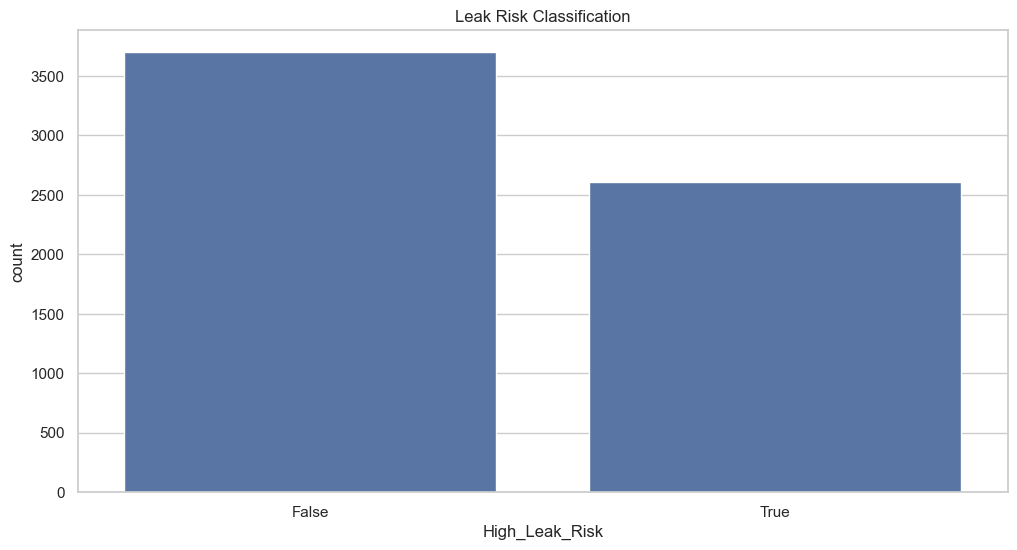

In [31]:
sns.countplot(data=trans, x="High_Leak_Risk")
plt.title("Leak Risk Classification")
plt.show()

## 7. DMA Zone Distribution

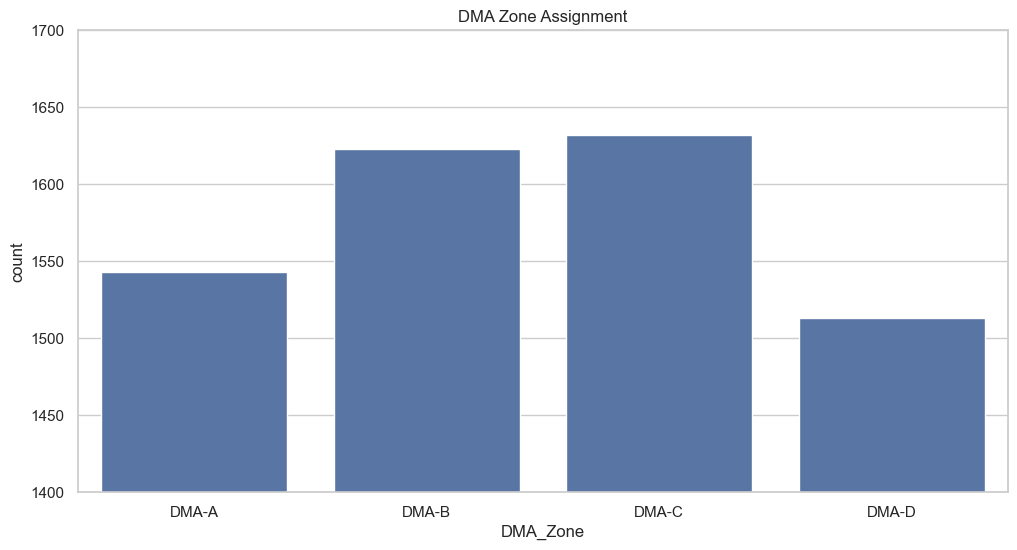

In [33]:
sns.countplot(data=trans, x="DMA_Zone")
plt.title("DMA Zone Assignment")
plt.ylim(1400,1700)
plt.show()

## Final Summary

In [34]:
summary = pd.DataFrame({
    "Dataset": ["Raw", "Cleaned", "Transformed"],
    "Rows": [raw.shape[0], clean.shape[0], trans.shape[0]],
    "Columns": [raw.shape[1], clean.shape[1], trans.shape[1]],
    "Missing": [
        raw.isnull().sum().sum(),
        clean.isnull().sum().sum(),
        trans.isnull().sum().sum()
    ]
})

summary

,Dataset,Rows,Columns,Missing
0,Raw,6501,16,5882
1,Cleaned,6312,17,5902
2,Transformed,6311,83,4077
